In [1]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from datetime import datetime
import csv
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import torch.nn.functional as F

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression
from helper_functions import *

In [2]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [ ]:
# adjust as needed to main path where data is. Should be 'DS6050_Ai_Detection' folder
data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")

# train/validate on percent of data. 0.1 = 10%, 1.0 = 100%
train_percent = 0.1

# adjust as needed for training device
batch_size = 16

# workers seem to be bugged, 0 works best
num_workers = 0

learning_rate = 1e-4

# using jpeg compression augmentation during training?
jpeg_compression = True

# number of epochs
num_epochs = 5

model_name = 'vit_fft'

# additional name to add at end of model name for logging and pth file
save_model_name = "regular"

make_images = True

# fft helper for dataloading
if 'fft' in model_name:
    fft = True
else:
    fft = False

In [4]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = main_data_loading(data_root, model_name, train_percent, 
                                                                                   batch_size, num_workers=num_workers, 
                                                                                   jpeg_compression=jpeg_compression)

Using model type: vit
Using FFT: False
Original class mapping: {'fake': 0, 'real': 1}
Using 10.0% of the data
Training on 11520 images, validating on 2834 images.
Saved dataset split CSV to: logs/dataset_split_20251206_174310.csv
Total records: 14354


In [5]:
confirm_labels(train_dataset, val_dataset)

Confirm correct labels
fake -> 1
real -> 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\010956.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\117162.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0033883.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\004497.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\059987.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\011806.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\012341.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0016687.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0023341.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\017221.png --> Label: 1


In [ ]:
# MODEL SETUP (ViT with FFT)

zero_init = True

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

old_conv = model.conv_proj
new_conv = nn.Conv2d(
    in_channels=6,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=(old_conv.bias is not None),
)

with torch.no_grad():

    if zero_init is True:
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3:] = 0.0
    else:
        new_conv.weight[:, :3, :, :] = old_conv.weight # RGB weights
        new_conv.weight[:, 3:, :, :] = old_conv.weight

    if old_conv.bias is not None:
        new_conv.bias.copy_(old_conv.bias)

model.conv_proj = new_conv

model.heads.head = nn.Sequential(
    nn.LayerNorm(model.heads.head.in_features),
    nn.Linear(model.heads.head.in_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # adding label smoothing for better generalization

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # adding L2 regularization

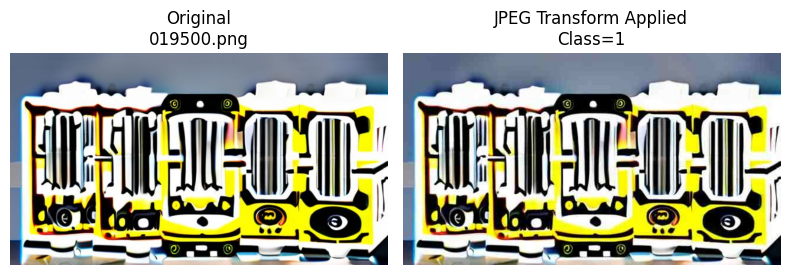

In [7]:
show_jpeg_transform_effect(val_dataset, index = 10, jpeg_q_range=(5, 60)) # range can go from 5 - 95

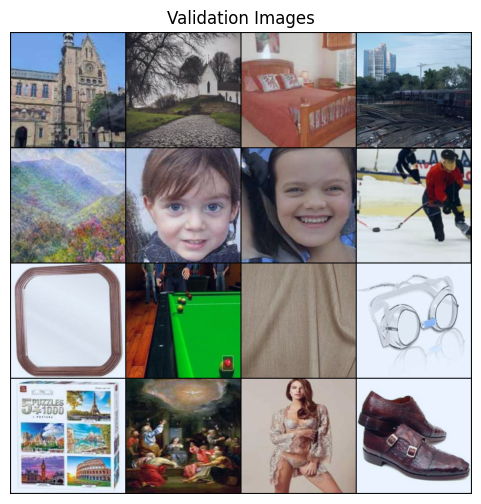

Fake: 022309.png
Fake: 026280.png
Fake: 020115.png
Fake: 030572.png
Fake: 001142.png
Fake: 017374.png
Fake: 015448.png
Fake: 034457.png
Real: 0008836.png
Real: 0020700.png
Real: 0025313.png
Real: 0000918.png
Real: 0013219.png
Real: 0025065.png
Real: 0024255.png
Real: 0030037.png


In [8]:
fixed_images, fixed_labels, grid_size = create_grid_of_val_images(val_dataset, grid_size=4, 
                                                                  fft=fft, device=device, keep=True)

In [ ]:
h = train_model(model=model, train_loader=train_loader, val_loader=val_loader,
                criterion=criterion, optimizer=optimizer, num_epochs=num_epochs,
                batch_size=batch_size, device=device, fft=fft,model_name=model_name, csv_name_used=csv_name,
                model_save_name=save_model_name, make_images=make_images, fixed_images=fixed_images,
                fixed_labels=fixed_labels, grid_size=grid_size)

Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

- Epoch 1/5


Training:   7%|▋         | 50/720 [00:12<02:39,  4.20batch/s, Loss=0.0397, Train Acc=70.25%]